<a href="https://colab.research.google.com/github/Ravindra1972/Anaytics-in-finance-using-Python/blob/main/Rebalancing_pynb.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt

In [ ]:
tickers = ["AAPL", "META","ACN", "ADBE", "AEE", "AMZN", "BSX", "CPB", "CVX",
           "DLR", "DLTR", "DPZ", "EA", "EBAY", "META", "FDX", "FOX", "GE","GOOGL",
           "HPE", "HD", "HON", "IEX", "INTC", "JNJ", "JPM", "KMB", "LRCX",
           "MAR", "MA", "MSFT", "MSI",  "NFLX", "NKE", "TCS", "ORCL", "PYPL",
           "PFE",  "QCOM", "REG", "SBUX", "TSLA", "ISRG", "UAL", "VZ",  "WFC",
           "WDC", "XEL", "YUM", "ZION"]

In [ ]:
stock_data = yf.download(tickers,start='2019-04-1', end='2025-11-22',interval='1mo')
stock_data = stock_data.dropna()


[*********************100%***********************]  49 of 49 completed


In [ ]:
stock_returns = pd.DataFrame()

In [ ]:
for ticker in tickers:
    stock_returns[ticker] = stock_data['Adj Close'][ticker].pct_change()

stock_returns = stock_returns.dropna()
sp500 = yf.download("^GSPC", start='2019-04-1', end='2024-07-19', interval='1mo')
sp500["monthly_returns"] = sp500["Adj Close"].pct_change().fillna(0)

[*********************100%***********************]  1 of 1 completed


In [ ]:
def portfolio(data, numStocks, numRev):
    df = data.copy()
    selected_stocks = []
    avg_monthly_ret = [0]
    for i in range(len(df)):
        if len(selected_stocks ) > 0:
            avg_monthly_ret.append(df[selected_stocks].iloc[i,:].mean())
            bad_stocks = df[selected_stocks].iloc[i,:].sort_values(ascending=True)[:numRev].index.values.tolist()
            selected_stocks  = [t for t in selected_stocks if t not in bad_stocks]
        fill = numStocks - len(selected_stocks)
        new_picks = df.iloc[i,:].sort_values(ascending=False)[:fill].index.values.tolist()
        selected_stocks  = selected_stocks  + new_picks
        print(selected_stocks)
    returns_df = pd.DataFrame(np.array(avg_monthly_ret),columns=["monthly_returns"])
    return returns_df

In [ ]:
def CAGR(data):
    df = data.copy()
    df['cumulative_returns'] = (1 + df['monthly_returns']).cumprod()
    trading_months = 12
    n = len(df)/ trading_months
    cagr = (df['cumulative_returns'][len(df)-1])**(1/n) - 1
    return cagr

In [ ]:
def volatility(data):
    df = data.copy()
    trading_months = 12
    vol = df['monthly_returns'].std() * np.sqrt(trading_months)
    return vol

In [ ]:
def sharpe_ratio(data, rf):
    df = data.copy()
    sharpe = (CAGR(df) - rf)/ volatility(df)
    return sharpe

In [ ]:
def maximum_drawdown(data):
    df = data.copy()
    df['cumulative_returns'] =  (1 + df['monthly_returns']).cumprod()
    df['cumulative_max'] = df['cumulative_returns'].cummax()
    df['drawdown'] = df['cumulative_max'] - df['cumulative_returns']
    df['drawdown_pct'] = df['drawdown'] / df['cumulative_max']
    max_dd = df['drawdown_pct'].max()
    return max_dd

In [ ]:
rebalanced_portfolio = portfolio(stock_returns, 5, 2)
print("Rebalanced Portfolio Performance")
print("CAGR: " + str(CAGR(rebalanced_portfolio)))
print("Sharpe Ratio: " + str(sharpe_ratio(rebalanced_portfolio, 0.03)))
print("Maximum Drawdown: " + str(maximum_drawdown(rebalanced_portfolio) ))


['MSI', 'BSX', 'DPZ', 'PFE', 'XEL']
['MSI', 'BSX', 'PFE', 'WDC', 'TSLA']
['MSI', 'WDC', 'TSLA', 'LRCX', 'WDC']
['MSI', 'WDC', 'WDC', 'CPB', 'MSI']
['WDC', 'WDC', 'CPB', 'DLTR', 'NKE']
['CPB', 'DLTR', 'NKE', 'TSLA', 'LRCX']
['CPB', 'NKE', 'TSLA', 'GE', 'FOX']
['CPB', 'NKE', 'TSLA', 'TSLA', 'WDC']
['TSLA', 'TSLA', 'WDC', 'TSLA', 'GE']
['TSLA', 'TSLA', 'TSLA', 'DPZ', 'NFLX']
['DPZ', 'NFLX', 'DLR', 'AMZN', 'CPB']
['DPZ', 'NFLX', 'AMZN', 'TSLA', 'EBAY']
['DPZ', 'TSLA', 'EBAY', 'TCS', 'PYPL']
['TSLA', 'EBAY', 'TCS', 'TSLA', 'UAL']
['TSLA', 'TCS', 'TSLA', 'TSLA', 'FDX']
['TSLA', 'TSLA', 'TSLA', 'TSLA', 'FDX']
['FDX', 'TCS', 'FDX', 'NKE', 'ORCL']
['FDX', 'TCS', 'FDX', 'TCS', 'GE']
['FDX', 'FDX', 'GE', 'TSLA', 'GE']
['GE', 'TSLA', 'GE', 'TSLA', 'WDC']
['TSLA', 'TSLA', 'WDC', 'TCS', 'EBAY']
['WDC', 'TCS', 'EBAY', 'UAL', 'MAR']
['TCS', 'EBAY', 'UAL', 'HD', 'DLTR']
['UAL', 'HD', 'DLTR', 'ISRG', 'WFC']
['UAL', 'HD', 'WFC', 'EBAY', 'MSI']
['HD', 'EBAY', 'MSI', 'ADBE', 'EBAY']
['HD', 'MSI', 'ADBE', '

In [ ]:
print("\n")

print("S&P500 Index Performance")
print("CAGR: " + str(CAGR(sp500)))
print("Sharpe Ratio: " + str(sharpe_ratio(sp500, 0.03)))
print("Maximum Drawdown: " + str(maximum_drawdown(sp500) ))



S&P500 Index Performance
CAGR: 0.1250480055700316
Sharpe Ratio: 0.5286451815612965
Maximum Drawdown: 0.2476952223905883


<ipython-input-11-b1187f579837>:6: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  cagr = (df['cumulative_returns'][len(df)-1])**(1/n) - 1
<ipython-input-11-b1187f579837>:6: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  cagr = (df['cumulative_returns'][len(df)-1])**(1/n) - 1


['MSI', 'BSX', 'DPZ', 'PFE', 'XEL']
['MSI', 'BSX', 'PFE', 'WDC', 'TSLA']
['MSI', 'WDC', 'TSLA', 'LRCX', 'WDC']
['MSI', 'WDC', 'WDC', 'CPB', 'MSI']
['WDC', 'WDC', 'CPB', 'DLTR', 'NKE']
['CPB', 'DLTR', 'NKE', 'TSLA', 'LRCX']
['CPB', 'NKE', 'TSLA', 'GE', 'FOX']
['CPB', 'NKE', 'TSLA', 'TSLA', 'WDC']
['TSLA', 'TSLA', 'WDC', 'TSLA', 'GE']
['TSLA', 'TSLA', 'TSLA', 'DPZ', 'NFLX']
['DPZ', 'NFLX', 'DLR', 'AMZN', 'CPB']
['DPZ', 'NFLX', 'AMZN', 'TSLA', 'EBAY']
['DPZ', 'TSLA', 'EBAY', 'TCS', 'PYPL']
['TSLA', 'EBAY', 'TCS', 'TSLA', 'UAL']
['TSLA', 'TCS', 'TSLA', 'TSLA', 'FDX']
['TSLA', 'TSLA', 'TSLA', 'TSLA', 'FDX']
['FDX', 'TCS', 'FDX', 'NKE', 'ORCL']
['FDX', 'TCS', 'FDX', 'TCS', 'GE']
['FDX', 'FDX', 'GE', 'TSLA', 'GE']
['GE', 'TSLA', 'GE', 'TSLA', 'WDC']
['TSLA', 'TSLA', 'WDC', 'TCS', 'EBAY']
['WDC', 'TCS', 'EBAY', 'UAL', 'MAR']
['TCS', 'EBAY', 'UAL', 'HD', 'DLTR']
['UAL', 'HD', 'DLTR', 'ISRG', 'WFC']
['UAL', 'HD', 'WFC', 'EBAY', 'MSI']
['HD', 'EBAY', 'MSI', 'ADBE', 'EBAY']
['HD', 'MSI', 'ADBE', '

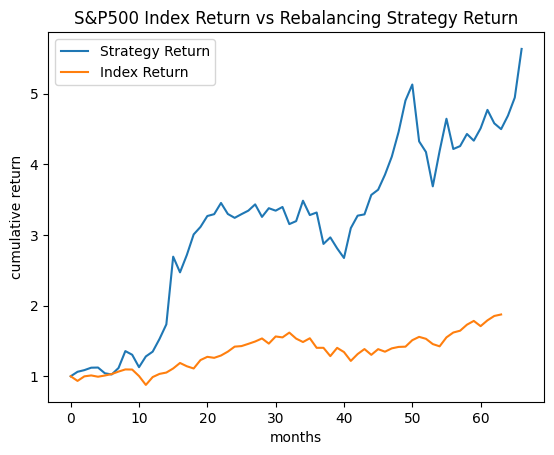

In [ ]:
fig, ax = plt.subplots()
plt.plot((1+portfolio(stock_returns, 5, 2)).cumprod())
plt.plot((1+sp500["monthly_returns"].reset_index(drop=True)).cumprod())
plt.title("S&P500 Index Return vs Rebalancing Strategy Return")
plt.ylabel("cumulative return")
plt.xlabel("months")
ax.legend(["Strategy Return","Index Return"])
